# Phase 3: Cross-model comparison

1. Setup. load all predictions
2. Headline metrics table. The one-table summary for the abstract
3. Side-by-side confusion matrices
4. Per-class breakdown across models
5. Per-view comparison (face-on vs down-the-line)
6. Controlled subset comparison. All three models evaluated on the same 48 frames
7. Cross-model agreement analysis

**Inputs** (saved in Phase 2):
- `data/results/predictions_pose_lr.parquet` - Pose+LR on full test (1026 frames)
- `data/results/predictions_pose_svm.parquet` - Pose+SVM on full test (1026 frames)  
- `data/results/predictions_cnn.parquet` - CNN on full test (1026 frames)
- `data/results/predictions_gpt5mini_cot_high.parquet`
- `data/results/predictions_gpt5mini_cot_high.parquet`

## 1. Setup and load predictions

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

PROCESSED_DIR = Path('../data/processed')
RESULTS_DIR = Path('../data/results')
EVENT_NAMES = ['Address', 'Toe-up', 'Mid-backswing', 'Top',
               'Mid-downswing', 'Impact', 'Mid-followthrough', 'Finish']

preds_lr = pd.read_parquet(RESULTS_DIR / 'predictions_pose_lr.parquet')
preds_svm = pd.read_parquet(RESULTS_DIR / 'predictions_pose_svm.parquet')
preds_cnn = pd.read_parquet(RESULTS_DIR / 'predictions_cnn.parquet')

print('Loaded full-test predictions:')
print(f'  Pose+LR:  {len(preds_lr)} predictions')
print(f'  Pose+SVM: {len(preds_svm)} predictions')
print(f'  CNN:      {len(preds_cnn)} predictions')

preds_llm = pd.read_parquet(RESULTS_DIR / 'predictions_gpt5mini_cot_high.parquet')
preds_llm['model'] = 'gpt5mini-cot-high'
print(f'  GPT-5 mini (CoT, high-detail): {len(preds_llm)} predictions')

lr_keys = set(zip(preds_lr['clip_id'], preds_lr['event_idx']))
cnn_keys = set(zip(preds_cnn['clip_id'], preds_cnn['event_idx']))
common = lr_keys & cnn_keys
print(f'\nSanity: pose+LR and CNN overlap on {len(common)} (clip, event) pairs')
print(f'  pose+LR only: {len(lr_keys - cnn_keys)}, CNN only: {len(cnn_keys - lr_keys)}')
if lr_keys != cnn_keys:
    print('  Note: pose+ML dropped some frames due to low pose-detection visibility.')
    print('  We will use the intersection for the controlled comparison.')

Loaded full-test predictions:
  Pose+LR:  478 predictions
  Pose+SVM: 478 predictions
  CNN:      478 predictions
  GPT-5 mini (CoT, high-detail): 48 predictions

Sanity: pose+LR and CNN overlap on 478 (clip, event) pairs
  pose+LR only: 0, CNN only: 0


## 2. Headline metrics table

The one table you'd put in the abstract. Each row a model; columns are accuracy, macro F1, per-view accuracy, and the sample size — to be transparent about the GPT-5 mini result being on a smaller subset.

In [2]:
def model_summary(preds_df: pd.DataFrame, label: str) -> dict:
    y_true = preds_df['true_label'].values
    y_pred = preds_df['predicted_label'].values
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', labels=EVENT_NAMES, zero_division=0)
    fo = preds_df[preds_df['view'] == 'face-on']
    dtl = preds_df[preds_df['view'] == 'down-the-line']
    fo_acc = accuracy_score(fo['true_label'], fo['predicted_label']) if len(fo) > 0 else np.nan
    dtl_acc = accuracy_score(dtl['true_label'], dtl['predicted_label']) if len(dtl) > 0 else np.nan
    return {
        'model': label,
        'n': len(preds_df),
        'accuracy': acc,
        'macro_f1': f1,
        'face_on_acc': fo_acc,
        'dtl_acc': dtl_acc,
        'view_gap': dtl_acc - fo_acc,
    }


headline = pd.DataFrame([
    model_summary(preds_lr, 'Pose + Logistic Regression'),
    model_summary(preds_svm, 'Pose + Linear SVM'),
    model_summary(preds_cnn, 'CNN — MobileNetV2'),
    model_summary(preds_llm, 'GPT-5 mini (CoT, high-detail) [n=48 subset]'),
])

print('=== HEADLINE METRICS ===')
print(headline.to_string(index=False, float_format=lambda v: f'{v:.3f}' if isinstance(v, float) else str(v)))

=== HEADLINE METRICS ===
                                      model   n  accuracy  macro_f1  face_on_acc  dtl_acc  view_gap
                 Pose + Logistic Regression 478     0.900     0.899        0.905    0.894    -0.011
                          Pose + Linear SVM 478     0.885     0.885        0.884    0.886     0.003
                          CNN — MobileNetV2 478     0.939     0.939        0.944    0.935    -0.009
GPT-5 mini (CoT, high-detail) [n=48 subset]  48     0.375     0.276        0.522    0.240    -0.282


## 3. Side-by-side confusion matrices

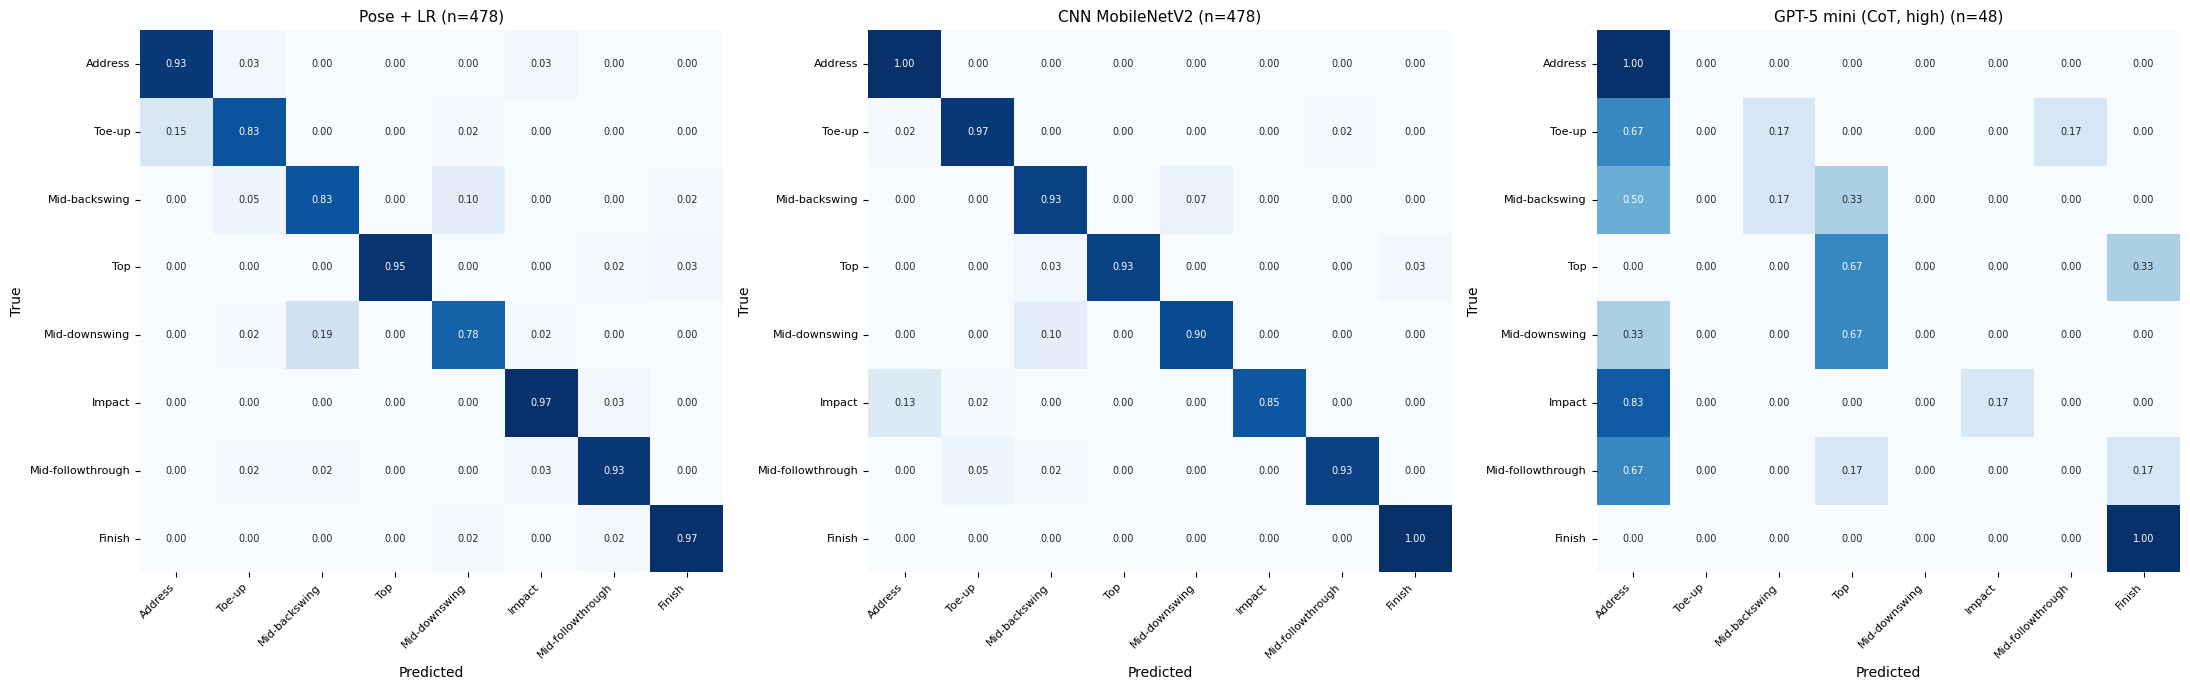

Saved figure to ..\data\results\confusion_matrices_three_models.png


In [3]:
def plot_cm(ax, preds_df, title, n_total):
    cm = confusion_matrix(
        preds_df['true_label'].values,
        preds_df['predicted_label'].values,
        labels=EVENT_NAMES, normalize='true',
    )
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=EVENT_NAMES, yticklabels=EVENT_NAMES,
                ax=ax, annot_kws={'size': 7})
    ax.set_title(f'{title} (n={n_total})', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(22, 7))
plot_cm(axes[0], preds_lr, 'Pose + LR', len(preds_lr))
plot_cm(axes[1], preds_cnn, 'CNN MobileNetV2', len(preds_cnn))
plot_cm(axes[2], preds_llm, 'GPT-5 mini (CoT, high)', len(preds_llm))
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'confusion_matrices_three_models.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved figure to {RESULTS_DIR / "confusion_matrices_three_models.png"}')

## 4. Per-class breakdown across models

Recall per class, side-by-side. Highlights which positions each model handles vs which it struggles with.

=== PER-CLASS RECALL ===
                   Pose+LR  Pose+SVM    CNN  GPT-5 mini (n=48)
Address              0.933     0.950  1.000              1.000
Toe-up               0.833     0.867  0.967              0.000
Mid-backswing        0.831     0.763  0.932              0.167
Top                  0.950     0.950  0.933              0.667
Mid-downswing        0.780     0.797  0.898              0.000
Impact               0.967     0.900  0.850              0.167
Mid-followthrough    0.933     0.900  0.933              0.000
Finish               0.967     0.950  1.000              1.000


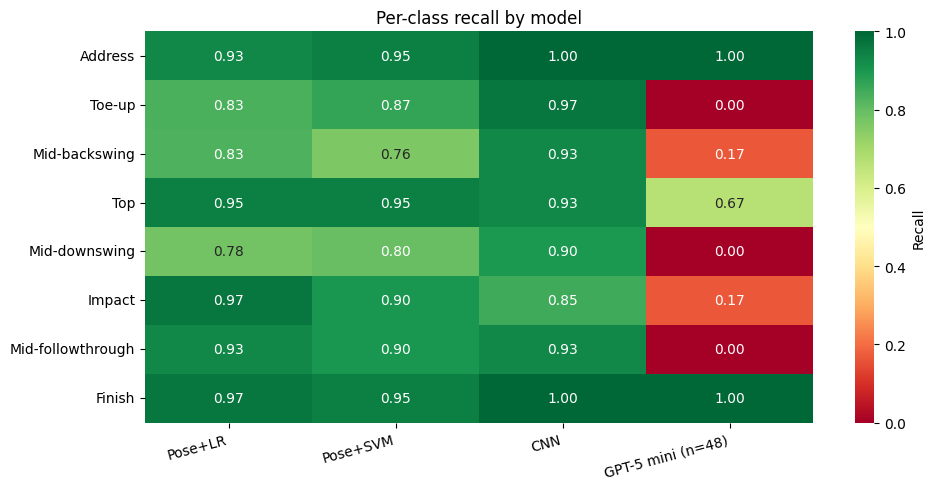

In [4]:
def per_class_recall(preds_df: pd.DataFrame) -> pd.Series:
    out = {}
    for cls in EVENT_NAMES:
        sub = preds_df[preds_df['true_label'] == cls]
        if len(sub) == 0:
            out[cls] = np.nan
        else:
            out[cls] = (sub['predicted_label'] == cls).mean()
    return pd.Series(out)


per_class_table = pd.DataFrame({
    'Pose+LR':            per_class_recall(preds_lr),
    'Pose+SVM':           per_class_recall(preds_svm),
    'CNN':                per_class_recall(preds_cnn),
    'GPT-5 mini (n=48)':  per_class_recall(preds_llm),
})

print('=== PER-CLASS RECALL ===')
print(per_class_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(per_class_table, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'Recall'}, ax=ax)
ax.set_title('Per-class recall by model')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'per_class_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Per-view comparison

Did the face-on/down-the-line gap that pose+ML showed close for the CNN? Does GPT-5 mini show a similar pattern?

=== ACCURACY BY VIEW ===
               Pose+LR    CNN  GPT-5 mini (n=48)
view                                            
face-on          0.905  0.944              0.522
down-the-line    0.894  0.935              0.240

View gap (DTL - face-on):
  Pose+LR                  : -0.011
  CNN                      : -0.009
  GPT-5 mini (n=48)        : -0.282


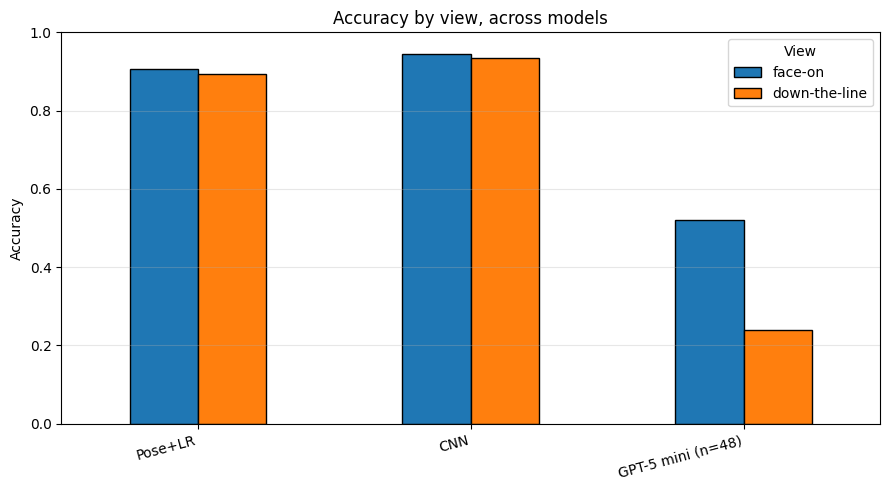

In [5]:
def per_view_table(preds_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for view in ['face-on', 'down-the-line']:
        sub = preds_df[preds_df['view'] == view]
        rows.append({
            'view': view,
            'n': len(sub),
            'accuracy': accuracy_score(sub['true_label'], sub['predicted_label']) if len(sub) > 0 else np.nan,
        })
    return pd.DataFrame(rows).set_index('view')


view_comparison = pd.DataFrame({
    'Pose+LR':           per_view_table(preds_lr)['accuracy'],
    'CNN':               per_view_table(preds_cnn)['accuracy'],
    'GPT-5 mini (n=48)': per_view_table(preds_llm)['accuracy'],
})

print('=== ACCURACY BY VIEW ===')
print(view_comparison.round(3).to_string())
print('\nView gap (DTL - face-on):')
for col in view_comparison.columns:
    gap = view_comparison.loc['down-the-line', col] - view_comparison.loc['face-on', col]
    print(f'  {col:25s}: {gap:+.3f}')

fig, ax = plt.subplots(figsize=(9, 5))
view_comparison.T.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by view, across models')
ax.set_ylim(0, 1.0)
ax.set_xticklabels(view_comparison.columns, rotation=15, ha='right')
ax.legend(title='View')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'accuracy_by_view.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Controlled subset comparison

All three models on the same 48 frames. This is the truly comparable view — no sample-size confound. The numbers will have wide error bars per class but the side-by-side comparison is honest.

In [6]:
subset_keys = set(zip(preds_llm['clip_id'], preds_llm['event_idx']))
print(f'Controlled subset size: {len(subset_keys)} frames')

def filter_to_subset(df, keys):
    return df[df.apply(lambda r: (r['clip_id'], r['event_idx']) in keys, axis=1)].copy()

preds_lr_sub = filter_to_subset(preds_lr, subset_keys)
preds_cnn_sub = filter_to_subset(preds_cnn, subset_keys)
preds_llm_sub = preds_llm.copy()  # already on the subset

print(f'  Pose+LR coverage on subset:  {len(preds_lr_sub)}/{len(subset_keys)}')
print(f'  CNN coverage on subset:      {len(preds_cnn_sub)}/{len(subset_keys)}')
print(f'  GPT-5 mini coverage:         {len(preds_llm_sub)}/{len(subset_keys)}')

if len(preds_lr_sub) < len(subset_keys):
    print('  Note: pose+LR coverage is short because some frames had pose-detection failures.')

controlled = pd.DataFrame([
    model_summary(preds_lr_sub, 'Pose + LR (on 48-frame subset)'),
    model_summary(preds_cnn_sub, 'CNN (on 48-frame subset)'),
    model_summary(preds_llm_sub, 'GPT-5 mini (on 48-frame subset)'),
])
print('\n=== CONTROLLED COMPARISON (matched subset) ===')
print(controlled.to_string(index=False, float_format=lambda v: f'{v:.3f}' if isinstance(v, float) else str(v)))

Controlled subset size: 48 frames
  Pose+LR coverage on subset:  48/48
  CNN coverage on subset:      48/48
  GPT-5 mini coverage:         48/48

=== CONTROLLED COMPARISON (matched subset) ===
                          model  n  accuracy  macro_f1  face_on_acc  dtl_acc  view_gap
 Pose + LR (on 48-frame subset) 48     0.938     0.937        1.000    0.880    -0.120
       CNN (on 48-frame subset) 48     0.896     0.891        0.870    0.920     0.050
GPT-5 mini (on 48-frame subset) 48     0.375     0.276        0.522    0.240    -0.282


In [7]:
# Side-by-side per-class on the controlled subset
controlled_per_class = pd.DataFrame({
    'Pose+LR':     per_class_recall(preds_lr_sub),
    'CNN':         per_class_recall(preds_cnn_sub),
    'GPT-5 mini':  per_class_recall(preds_llm_sub),
})
print('=== PER-CLASS RECALL ON CONTROLLED 48-FRAME SUBSET ===')
print('(Note: only ~6 frames per class, so per-class numbers have large error bars.)')
print(controlled_per_class.round(2).to_string())

=== PER-CLASS RECALL ON CONTROLLED 48-FRAME SUBSET ===
(Note: only ~6 frames per class, so per-class numbers have large error bars.)
                   Pose+LR   CNN  GPT-5 mini
Address               1.00  1.00        1.00
Toe-up                0.83  0.83        0.00
Mid-backswing         0.83  1.00        0.17
Top                   0.83  0.83        0.67
Mid-downswing         1.00  1.00        0.00
Impact                1.00  0.50        0.17
Mid-followthrough     1.00  1.00        0.00
Finish                1.00  1.00        1.00


## 7. Cross-model agreement analysis

On the controlled 48-frame subset where all three models gave predictions, how often do they agree? When they disagree, who's right?

This is small-sample diagnostic, not a precision benchmark — but it surfaces interesting qualitative patterns about whether the models are making the same kinds of mistakes (suggesting task-intrinsic difficulty) or different kinds (suggesting model-specific biases).

In [8]:
def to_keyed(df, model_label):
    return df.set_index(['clip_id', 'event_idx'])[['true_label', 'predicted_label']].rename(
        columns={'predicted_label': f'pred_{model_label}'}
    )

lr_k = to_keyed(preds_lr_sub, 'lr')
cnn_k = to_keyed(preds_cnn_sub, 'cnn')
llm_k = to_keyed(preds_llm_sub, 'llm')

joined = lr_k[['true_label', 'pred_lr']].join(
    cnn_k[['pred_cnn']], how='inner'
).join(
    llm_k[['pred_llm']], how='inner'
).reset_index()

print(f'Frames where all three models predicted: {len(joined)}')

joined['lr_correct'] = joined['pred_lr'] == joined['true_label']
joined['cnn_correct'] = joined['pred_cnn'] == joined['true_label']
joined['llm_correct'] = joined['pred_llm'] == joined['true_label']

print('\n=== AGREEMENT BREAKDOWN ===')
all_three_agree = (joined['pred_lr'] == joined['pred_cnn']) & (joined['pred_cnn'] == joined['pred_llm'])
lr_cnn_agree = (joined['pred_lr'] == joined['pred_cnn']) & (joined['pred_cnn'] != joined['pred_llm'])
lr_llm_agree = (joined['pred_lr'] == joined['pred_llm']) & (joined['pred_lr'] != joined['pred_cnn'])
cnn_llm_agree = (joined['pred_cnn'] == joined['pred_llm']) & (joined['pred_cnn'] != joined['pred_lr'])
all_disagree = (
    (joined['pred_lr'] != joined['pred_cnn']) &
    (joined['pred_cnn'] != joined['pred_llm']) &
    (joined['pred_lr'] != joined['pred_llm'])
)

print(f'  All three agree:           {all_three_agree.sum():3d}/{len(joined)}')
print(f'    ...and they\'re right:    {(all_three_agree & joined["lr_correct"]).sum():3d}')
print(f'    ...and they\'re wrong:    {(all_three_agree & ~joined["lr_correct"]).sum():3d}')
print(f'  LR + CNN agree (LLM diff):  {lr_cnn_agree.sum():3d}/{len(joined)}')
print(f'    ...LR+CNN right:          {(lr_cnn_agree & joined["lr_correct"]).sum():3d}')
print(f'    ...LLM right:             {(lr_cnn_agree & joined["llm_correct"]).sum():3d}')
print(f'  LR + LLM agree (CNN diff):  {lr_llm_agree.sum():3d}/{len(joined)}')
print(f'    ...LR+LLM right:          {(lr_llm_agree & joined["lr_correct"]).sum():3d}')
print(f'    ...CNN right:             {(lr_llm_agree & joined["cnn_correct"]).sum():3d}')
print(f'  CNN + LLM agree (LR diff):  {cnn_llm_agree.sum():3d}/{len(joined)}')
print(f'    ...CNN+LLM right:         {(cnn_llm_agree & joined["cnn_correct"]).sum():3d}')
print(f'    ...LR right:              {(cnn_llm_agree & joined["lr_correct"]).sum():3d}')
print(f'  All three disagree:         {all_disagree.sum():3d}/{len(joined)}')
print(f'    ...LR right:              {(all_disagree & joined["lr_correct"]).sum():3d}')
print(f'    ...CNN right:             {(all_disagree & joined["cnn_correct"]).sum():3d}')
print(f'    ...LLM right:             {(all_disagree & joined["llm_correct"]).sum():3d}')
print(f'    ...nobody right:          {(all_disagree & ~joined["lr_correct"] & ~joined["cnn_correct"] & ~joined["llm_correct"]).sum():3d}')

Frames where all three models predicted: 48

=== AGREEMENT BREAKDOWN ===
  All three agree:            16/48
    ...and they're right:     16
    ...and they're wrong:      0
  LR + CNN agree (LLM diff):   24/48
    ...LR+CNN right:           24
    ...LLM right:               0
  LR + LLM agree (CNN diff):    2/48
    ...LR+LLM right:            1
    ...CNN right:               1
  CNN + LLM agree (LR diff):    5/48
    ...CNN+LLM right:           1
    ...LR right:                4
  All three disagree:           1/48
    ...LR right:                0
    ...CNN right:               1
    ...LLM right:               0
    ...nobody right:            0


In [9]:
pair_agreement = pd.DataFrame({
    'LR vs CNN':  [(joined['pred_lr'] == joined['pred_cnn']).mean()],
    'LR vs LLM':  [(joined['pred_lr'] == joined['pred_llm']).mean()],
    'CNN vs LLM': [(joined['pred_cnn'] == joined['pred_llm']).mean()],
}, index=['agreement_rate'])
print('\n=== PAIRWISE AGREEMENT RATES ===')
print(pair_agreement.round(3).to_string())

from itertools import product

pattern_counts = joined.groupby(['lr_correct', 'cnn_correct', 'llm_correct']).size()
print('\n=== "WHO GOT IT RIGHT" BREAKDOWN ===')
for (lr_c, cnn_c, llm_c) in product([True, False], repeat=3):
    n = pattern_counts.get((lr_c, cnn_c, llm_c), 0)
    if n == 0:
        continue
    correct_set = []
    if lr_c: correct_set.append('LR')
    if cnn_c: correct_set.append('CNN')
    if llm_c: correct_set.append('LLM')
    label = '+'.join(correct_set) if correct_set else 'NONE'
    print(f'  Right: {label:15s}  count={n}')


=== PAIRWISE AGREEMENT RATES ===
                LR vs CNN  LR vs LLM  CNN vs LLM
agreement_rate      0.833      0.375       0.438

=== "WHO GOT IT RIGHT" BREAKDOWN ===
  Right: LR+CNN+LLM       count=16
  Right: LR+CNN           count=24
  Right: LR+LLM           count=1
  Right: LR               count=4
  Right: CNN+LLM          count=1
  Right: CNN              count=2


In [10]:
# Save the final tables for the report
headline.to_csv(RESULTS_DIR / 'headline_metrics.csv', index=False)
per_class_table.to_csv(RESULTS_DIR / 'per_class_recall.csv')
view_comparison.to_csv(RESULTS_DIR / 'per_view_accuracy.csv')
controlled.to_csv(RESULTS_DIR / 'controlled_subset_metrics.csv', index=False)
controlled_per_class.to_csv(RESULTS_DIR / 'controlled_subset_per_class.csv')
joined.to_csv(RESULTS_DIR / 'cross_model_predictions.csv', index=False)
print(f'Saved comparison tables to {RESULTS_DIR}')

Saved comparison tables to ..\data\results
